<a href="https://colab.research.google.com/github/vishalnaidu07/BULIDING_VIBRATION_MODE_ANALYZER/blob/main/SMART_VIBE_PART_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

             BUILDING VIBRATION MODE ANALYZER

Mass Matrix M:
[[20000.     0.     0.]
 [    0. 20000.     0.]
 [    0.     0. 20000.]]

Stiffness Matrix K:
[[ 40000000. -20000000.         0.]
 [-20000000.  40000000. -20000000.]
 [        0. -20000000.  20000000.]]

                    NATURAL FREQUENCIES
Mode      Eigenvalue (omega^2)     Omega (rad/s)       Frequency (Hz)      
----------------------------------------------------------------------
1         198.06226                14.07346            2.23986             
2         1554.95813               39.43296            6.27595             
3         3246.97960               56.98227            9.06901             

                       MODE SHAPES

Normalized floor displacement:
Floor     Mode 1         Mode 2         Mode 3         
-------------------------------------------------------
1         0.4450         -1.0000        -0.8019        
2         0.8019         -0.4450        1.0000         
3         1.0000         0.

Matrix([
[m1,  0,  0],
[ 0, m2,  0],
[ 0,  0, m3]])


Symbolic Stiffness Matrix K:


Matrix([
[k1 + k2,     -k2,   0],
[    -k2, k2 + k3, -k3],
[      0,     -k3,  k3]])

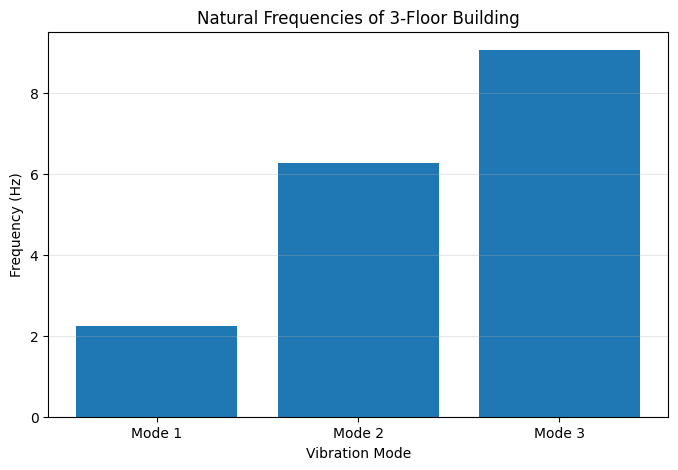

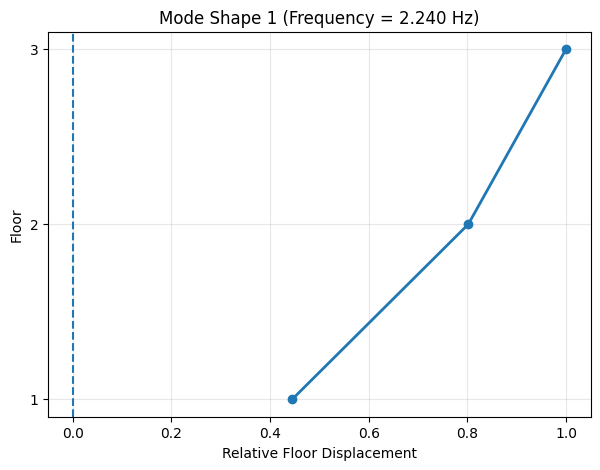

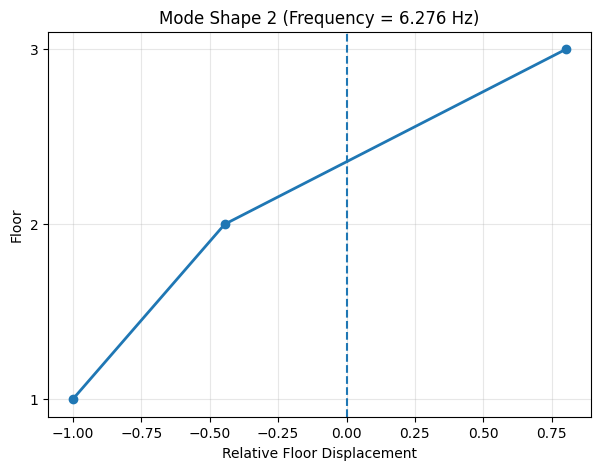

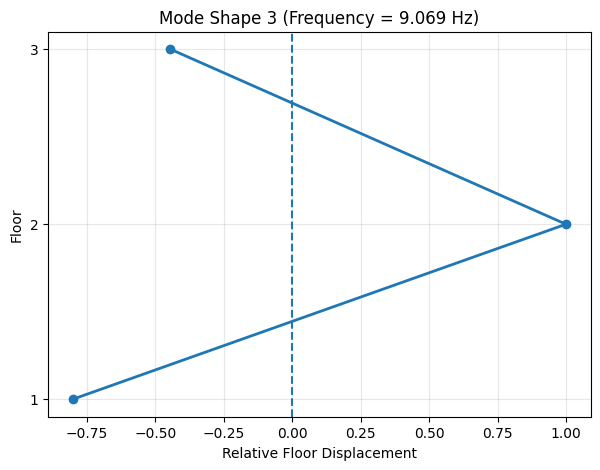

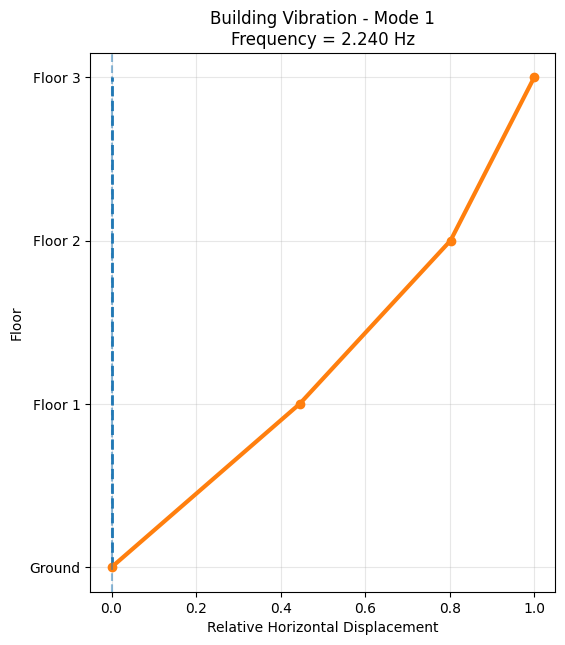

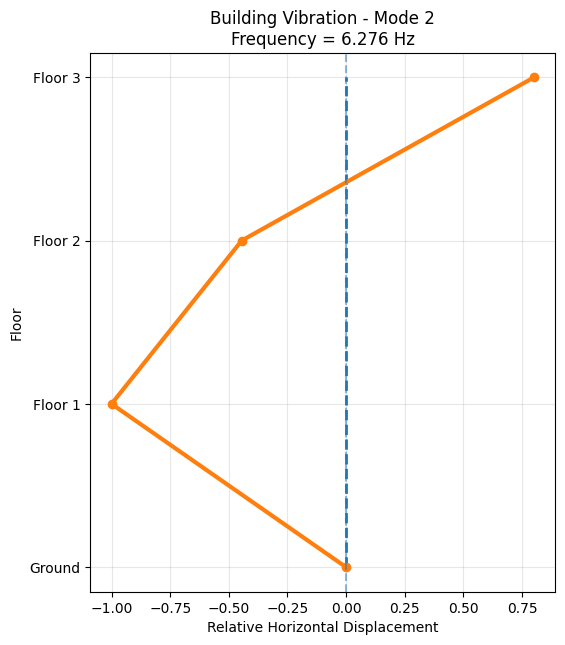

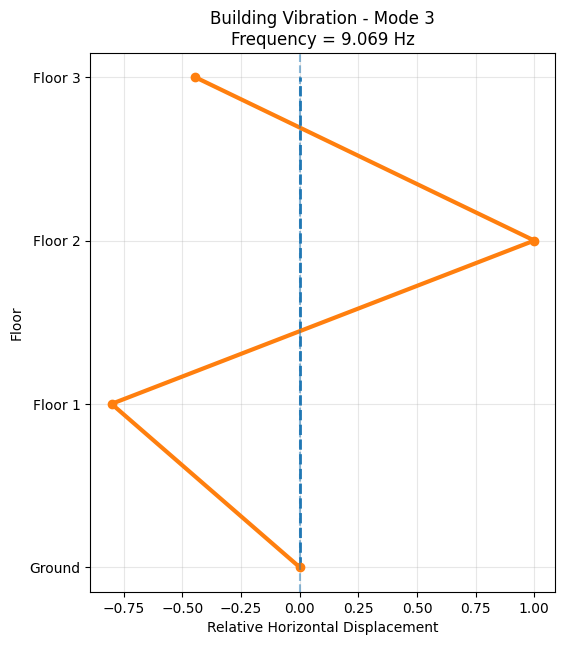


                         FINAL RESULT
Mode 1: Natural Frequency = 2.2399 Hz
Mode 2: Natural Frequency = 6.2760 Hz
Mode 3: Natural Frequency = 9.0690 Hz

Project completed successfully!
Eigenvalues represent omega^2.
Eigenvectors represent the vibration mode shapes.
The mode shapes show how each floor moves in each mode.


In [ ]:
# ============================================================
# BUILDING VIBRATION MODE ANALYZER
# B.Tech Mathematics Mini Project
# ============================================================
#
# Mathematical Model:
#     K v = omega^2 M v
#
# K = Stiffness Matrix
# M = Mass Matrix
# v = Mode Shape (Eigenvector)
# omega^2 = Eigenvalue
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

np.set_printoptions(precision=5, suppress=True)


# ============================================================
# 1. INPUTS
# ============================================================

# Floor masses (kg)
masses = np.array([
    20000,   # Floor 1
    20000,   # Floor 2
    20000    # Floor 3
], dtype=float)

# Story stiffnesses (N/m)
stiffnesses = np.array([
    2.0e7,   # Story 1
    2.0e7,   # Story 2
    2.0e7    # Story 3
], dtype=float)


# ============================================================
# 2. MASS MATRIX M
# ============================================================

M = np.diag(masses)

print("=" * 70)
print("             BUILDING VIBRATION MODE ANALYZER")
print("=" * 70)

print("\nMass Matrix M:")
print(M)


# ============================================================
# 3. STIFFNESS MATRIX K
# ============================================================

k1, k2, k3 = stiffnesses

K = np.array([
    [k1 + k2,   -k2,        0],
    [-k2,       k2 + k3,   -k3],
    [0,         -k3,        k3]
], dtype=float)

print("\nStiffness Matrix K:")
print(K)


# ============================================================
# 4. GENERALIZED EIGENVALUE PROBLEM
# ============================================================
#
#        K v = omega^2 M v
#
# We convert it to a standard symmetric eigenvalue problem:
#
#        A u = omega^2 u
#
# where
#
#        A = M^(-1/2) K M^(-1/2)
#
# ============================================================

M_inv_sqrt = np.diag(1 / np.sqrt(masses))

A = M_inv_sqrt @ K @ M_inv_sqrt


# ============================================================
# 5. CALCULATE EIGENVALUES AND EIGENVECTORS
# ============================================================

eigenvalues, U = np.linalg.eigh(A)

# Eigenvalues = omega^2
omega_squared = eigenvalues

# Angular frequencies (rad/s)
omega = np.sqrt(omega_squared)

# Natural frequencies (Hz)
frequencies_hz = omega / (2 * np.pi)

# Convert eigenvectors to original floor coordinates
mode_shapes = M_inv_sqrt @ U


# ============================================================
# 6. NORMALIZE MODE SHAPES
# ============================================================

for i in range(3):
    mode_shapes[:, i] /= np.max(np.abs(mode_shapes[:, i]))


# ============================================================
# 7. DISPLAY NATURAL FREQUENCIES
# ============================================================

print("\n" + "=" * 70)
print("                    NATURAL FREQUENCIES")
print("=" * 70)

print(f"{'Mode':<10}{'Eigenvalue (omega^2)':<25}"
      f"{'Omega (rad/s)':<20}{'Frequency (Hz)':<20}")

print("-" * 70)

for i in range(3):
    print(
        f"{i+1:<10}"
        f"{omega_squared[i]:<25.5f}"
        f"{omega[i]:<20.5f}"
        f"{frequencies_hz[i]:<20.5f}"
    )


# ============================================================
# 8. DISPLAY MODE SHAPES
# ============================================================

print("\n" + "=" * 70)
print("                       MODE SHAPES")
print("=" * 70)

print("\nNormalized floor displacement:")

print(f"{'Floor':<10}{'Mode 1':<15}{'Mode 2':<15}{'Mode 3':<15}")
print("-" * 55)

for floor in range(3):
    print(
        f"{floor+1:<10}"
        f"{mode_shapes[floor, 0]:<15.4f}"
        f"{mode_shapes[floor, 1]:<15.4f}"
        f"{mode_shapes[floor, 2]:<15.4f}"
    )


# ============================================================
# 9. VERIFY Kv = omega^2 Mv
# ============================================================

print("\n" + "=" * 70)
print("                       VERIFICATION")
print("=" * 70)

for i in range(3):

    v = mode_shapes[:, i]

    left_side = K @ v
    right_side = omega_squared[i] * (M @ v)

    error = np.linalg.norm(left_side - right_side)

    print(f"\nMode {i+1}")
    print("Verification Error:", error)


# ============================================================
# 10. SYMBOLIC MATRICES
# ============================================================

m1, m2, m3 = sp.symbols("m1 m2 m3", positive=True)
k1s, k2s, k3s = sp.symbols("k1 k2 k3", positive=True)

M_symbolic = sp.Matrix([
    [m1, 0, 0],
    [0, m2, 0],
    [0, 0, m3]
])

K_symbolic = sp.Matrix([
    [k1s + k2s, -k2s, 0],
    [-k2s, k2s + k3s, -k3s],
    [0, -k3s, k3s]
])

print("\n" + "=" * 70)
print("                 SYMBOLIC MASS MATRIX M")
print("=" * 70)

display(M_symbolic)

print("\nSymbolic Stiffness Matrix K:")
display(K_symbolic)


# ============================================================
# 11. NATURAL FREQUENCY BAR CHART
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    ["Mode 1", "Mode 2", "Mode 3"],
    frequencies_hz
)

plt.title("Natural Frequencies of 3-Floor Building")
plt.xlabel("Vibration Mode")
plt.ylabel("Frequency (Hz)")
plt.grid(axis="y", alpha=0.3)

plt.show()


# ============================================================
# 12. MODE SHAPE GRAPHS
# ============================================================

floors = np.array([1, 2, 3])

for mode in range(3):

    plt.figure(figsize=(7, 5))

    plt.plot(
        mode_shapes[:, mode],
        floors,
        marker="o",
        linewidth=2
    )

    plt.axvline(0, linestyle="--")

    plt.title(
        f"Mode Shape {mode+1} "
        f"(Frequency = {frequencies_hz[mode]:.3f} Hz)"
    )

    plt.xlabel("Relative Floor Displacement")
    plt.ylabel("Floor")

    plt.yticks([1, 2, 3])

    plt.grid(True, alpha=0.3)

    plt.show()


# ============================================================
# 13. BUILDING MODE VISUALIZATION
# ============================================================

for mode in range(3):

    plt.figure(figsize=(6, 7))

    # Original building
    plt.plot(
        [0, 0, 0, 0],
        [0, 1, 2, 3],
        linestyle="--",
        linewidth=2
    )

    # Deformed building
    x = np.concatenate(([0], mode_shapes[:, mode]))
    y = np.array([0, 1, 2, 3])

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=3
    )

    plt.axvline(0, linestyle="--", alpha=0.5)

    plt.title(
        f"Building Vibration - Mode {mode+1}\n"
        f"Frequency = {frequencies_hz[mode]:.3f} Hz"
    )

    plt.xlabel("Relative Horizontal Displacement")
    plt.ylabel("Floor")

    plt.yticks(
        [0, 1, 2, 3],
        ["Ground", "Floor 1", "Floor 2", "Floor 3"]
    )

    plt.grid(True, alpha=0.3)

    plt.show()


# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("                         FINAL RESULT")
print("=" * 70)

for i in range(3):

    print(
        f"Mode {i+1}: "
        f"Natural Frequency = {frequencies_hz[i]:.4f} Hz"
    )

print("\nProject completed successfully!")
print("Eigenvalues represent omega^2.")
print("Eigenvectors represent the vibration mode shapes.")
print("The mode shapes show how each floor moves in each mode.")